In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('vgsales.csv')

In [4]:
df.head(10)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989.0,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,7,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,8,Wii Play,Wii,2006.0,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02
8,9,New Super Mario Bros. Wii,Wii,2009.0,Platform,Nintendo,14.59,7.06,4.70,2.26,28.62
9,10,Duck Hunt,NES,1984.0,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31


2 задание

In [5]:
{df.shape[0]}

{16598}

кол-во строк

In [6]:
{df.shape[1]}

{11}

кол-во столбцов

In [10]:
list(df.columns)

['Rank',
 'Name',
 'Platform',
 'Year',
 'Genre',
 'Publisher',
 'NA_Sales',
 'EU_Sales',
 'JP_Sales',
 'Other_Sales',
 'Global_Sales']

названия столбцов

In [11]:
df.dtypes

,0
Rank,int64
Name,object
Platform,object
Year,float64
Genre,object
Publisher,object
NA_Sales,float64
EU_Sales,float64
JP_Sales,float64
Other_Sales,float64


типы данных

In [12]:
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


основные статистические характеристики

3 задание

In [13]:
df.isnull().sum()

,0
Rank,0
Name,0
Platform,0
Year,271
Genre,0
Publisher,58
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0


кол-во пропусков в каждом столбце


In [15]:
df[df['Year'].isnull()].head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
179,180,Madden NFL 2004,PS2,NaN,Sports,Electronic Arts,4.26,0.26,0.01,0.71,5.23
377,378,FIFA Soccer 2004,PS2,NaN,Sports,Electronic Arts,0.59,2.36,0.04,0.51,3.49
431,432,LEGO Batman: The Videogame,Wii,NaN,Action,Warner Bros. Interactive Entertainment,1.86,1.02,0.00,0.29,3.17
470,471,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,NaN,1.57,1.02,0.00,0.41,3.00
607,608,Space Invaders,2600,NaN,Shooter,Atari,2.36,0.14,0.00,0.03,2.53


вывод где отсутствует значение year


пропуски есть в столбцах Year и Publisher

кол-во пропущеных значений 271 и 58

больше всего пропусков у year

4 задание

In [16]:
df_clean = df.dropna(subset=["Year"])

создали очищенный набор данных

In [19]:
df_clean.shape


(16327, 11)

In [20]:
df_clean.isnull().sum()

,0
Rank,0
Name,0
Platform,0
Year,0
Genre,0
Publisher,36
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0


было 16598

после удаления осталось 16327(удалили 271)

год выпуска влияет на анлиз трендов. отсутствие года мешает сделать корректную временнуб группировку или построение груфиков по годам для этих игр.

5 задание

In [35]:
print(f"Жанры ({df_clean['Genre'].nunique()}): {df_clean['Genre'].unique()}")

Жанры (12): ['Sports' 'Platform' 'Racing' 'Role-Playing' 'Puzzle' 'Misc' 'Shooter'
 'Simulation' 'Action' 'Fighting' 'Adventure' 'Strategy']


жанры и их количество

In [36]:
print(f"Платформы ({df_clean['Platform'].nunique()}): {df_clean['Platform'].unique()}")

Платформы (31): ['Wii' 'NES' 'GB' 'DS' 'X360' 'PS3' 'PS2' 'SNES' 'GBA' '3DS' 'PS4' 'N64'
 'PS' 'XB' 'PC' '2600' 'PSP' 'XOne' 'GC' 'WiiU' 'GEN' 'DC' 'PSV' 'SAT'
 'SCD' 'WS' 'NG' 'TG16' '3DO' 'GG' 'PCFX']


платформы и их количество

In [24]:
df_clean['Publisher'].nunique()

576

издатели и их количество

предщставлено 12 жанров

31 платформа

576 издателей

больше всего уникальных значений имеет признак Publisher - издатель

6 задание

In [41]:
genre_count = df_clean.groupby("Genre")["Name"].count().sort_values(ascending=False)
print(genre_count)

Genre
Action          3253
Sports          2304
Misc            1710
Role-Playing    1471
Shooter         1282
Adventure       1276
Racing          1226
Platform         876
Simulation       851
Fighting         836
Strategy         671
Puzzle           571
Name: Name, dtype: int64


количество игр каждого жанра

7 задание

In [42]:
genre_sales = df_clean.groupby("Genre")["Global_Sales"].sum().sort_values(ascending=False)
print(genre_sales)

Genre
Action          1722.88
Sports          1309.24
Shooter         1026.20
Role-Playing     923.84
Platform         829.15
Misc             797.62
Racing           726.77
Fighting         444.05
Simulation       390.16
Puzzle           242.22
Adventure        234.80
Strategy         173.43
Name: Global_Sales, dtype: float64


мировые продажи

8 задание

In [43]:
top_10_games = df_clean.nlargest(10, 'Global_Sales')[["Rank", "Name", "Platform", "Genre", "Global_Sales"]]
print(top_10_games.to_string(index=False))

 Rank                      Name Platform        Genre  Global_Sales
    1                Wii Sports      Wii       Sports         82.74
    2         Super Mario Bros.      NES     Platform         40.24
    3            Mario Kart Wii      Wii       Racing         35.82
    4         Wii Sports Resort      Wii       Sports         33.00
    5  Pokemon Red/Pokemon Blue       GB Role-Playing         31.37
    6                    Tetris       GB       Puzzle         30.26
    7     New Super Mario Bros.       DS     Platform         30.01
    8                  Wii Play      Wii         Misc         29.02
    9 New Super Mario Bros. Wii      Wii     Platform         28.62
   10                 Duck Hunt      NES      Shooter         28.31


топ 10 игр с макс мировыми продажами и только итересующие столбцы

9 задание

In [45]:
platform_count = df_clean.groupby("Platform")["Name"].count().sort_values(ascending=False).head(10)
print(platform_count)

Platform
DS      2133
PS2     2127
PS3     1304
Wii     1290
X360    1235
PSP     1197
PS      1189
PC       943
GBA      811
XB       803
Name: Name, dtype: int64


количество игр для каждой платформы и их топ 10

In [46]:
platform_sales = df_clean.groupby("Platform")["Global_Sales"].sum().sort_values(ascending=False).head(10)
print(platform_sales)

Platform
PS2     1233.46
X360     969.61
PS3      949.35
Wii      909.81
DS       818.96
PS       727.39
GBA      313.56
PSP      291.71
PS4      278.10
PC       255.05
Name: Global_Sales, dtype: float64


топ 10 платформ по суммарным продажам

10 задание

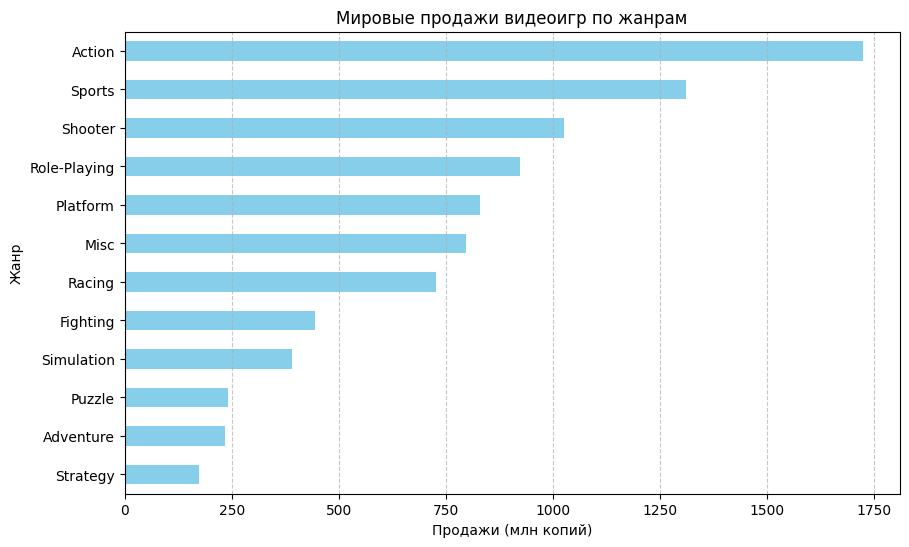

In [47]:
plt.figure(figsize=(10, 6))
genre_sales.sort_values().plot(kind='barh', color='skyblue')
plt.title('Мировые продажи видеоигр по жанрам')
plt.xlabel('Продажи (млн копий)')
plt.ylabel('Жанр')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

наибольшие продажи у Action, Sports и Shooter.

наименьшие продажи у Strategy, Adventure и Puzzle.

разница очень сильно, примерно в 10 раз

11 задание

In [48]:
corr_na_global = df_clean[["NA_Sales", "Global_Sales"]].corr()
print(corr_na_global)

              NA_Sales  Global_Sales
NA_Sales      1.000000      0.941268
Global_Sales  0.941268      1.000000


корреляция = 0.941

значение положительное

оно очень близко к 1

между ними очень сильная связь. чем выше продажи в сев америке, тем выше мировые продажи

12 задание

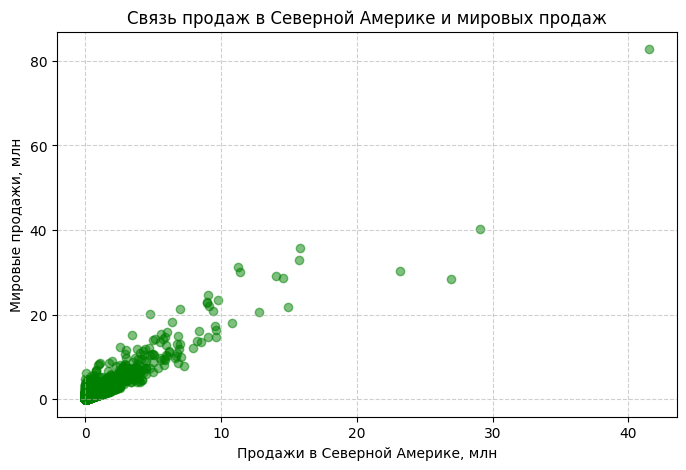

In [50]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df_clean["NA_Sales"],
    df_clean["Global_Sales"],
    alpha=0.5,
    color='green'
)
plt.xlabel('Продажи в Северной Америке, млн')
plt.ylabel('Мировые продажи, млн')
plt.title('Связь продаж в Северной Америке и мировых продаж')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

одна точка - это конкретная игра.

да, восходящая тенденция имеется

да, линейная группировка точек подтверждает высокий коэффициент корреляции

13 задание

In [51]:
regions_corr = df_clean[["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]].corr()
print(regions_corr)

             NA_Sales  EU_Sales  JP_Sales  Other_Sales
NA_Sales     1.000000  0.768936  0.451285     0.634508
EU_Sales     0.768936  1.000000  0.436414     0.726266
JP_Sales     0.451285  0.436414  1.000000     0.290653
Other_Sales  0.634508  0.726266  0.290653     1.000000


сильно связаны NA_Sales и EU_Sales, а так же EU_Sales и Other_Sales

Проведённый анализ показал, что предварительная очистка данных и удаление пропусков не привели к значительной потере информации, а применение методов группировки и корреляционного анализа позволило выявить ключевые закономерности рынка видеоигр: доминирование жанров Action и Sports, ведущую роль платформы PS2 и сильную зависимость мировых продаж от североамериканского рынка при относительной независимости японского сегмента.